# PREPARATION ET NETTOYAGE DES DONNEES

In [1]:
#Importation des librairies
import numpy as np
import pandas as pd
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Extraction et nettoyage des données

### A. Population mondiale

In [2]:
#chargement du fichier
population = pd.read_csv(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\Population_2000_2018.csv")
population.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [3]:
#Filtre sur année 2017 (année en commmun pour toutes les données)
population = population.loc[population['Année'] == 2017,:]
#Conversion en nombre d'habitants (au lieu du nombre d'habitants pour 1000 personnes)
population["Nombre d'habitants"] = population['Valeur'] * 1000
#Sélection des données pertinentes
population = population[['Zone',"Nombre d'habitants"]]

In [4]:
#Ajout du code pays pour pouvoir fusionner avec les autres données
##Création du dictionnaire
country_code = pd.read_csv(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\country_code.csv")
country_code = country_code[['official_name_fr','ISO3166-1-Alpha-3']]
dict_pays = (dict(zip(country_code['official_name_fr'], country_code['ISO3166-1-Alpha-3'])))
dict_pays["Antilles néerlandaises (ex)"] = "ANT"
dict_pays["Chine - RAS de Hong-Kong"] = "HKG"
dict_pays["Chine - RAS de Macao"] = "MAC"
dict_pays["Chine, continentale"] = "CHN"
dict_pays["Chine, Taiwan Province de"] = "TWN"
dict_pays["Côte d'Ivoire"] = "CIV"
dict_pays["États-Unis d'Amérique"] = "USA"
dict_pays["Îles Anglo-Normandes"] = "CHI"
dict_pays["Iran (République islamique d')"] = "IRN"
dict_pays["Palestine"] = "PSE"
dict_pays["Pays-Bas"] = "NLD"
dict_pays["Royaume-Uni de Grande-Bretagne et d'Irlande du Nord"] = "GBR"
dict_pays["Sainte-Hélène, Ascension et Tristan da Cunha"] = "SHN"
dict_pays["Sint Maarten  (partie néerlandaise)"] = "SXM"
dict_pays["Turquie"] = "TUR"

##Ajout du code pays dans le df population grâce au dictionnaire
population['Code pays'] = population['Zone'].map(dict_pays)

In [5]:
#infos sur le fichier
print(population.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in population.columns.values:
    print(f"{col} : {population[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 236 entries, 17 to 4409
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Zone                236 non-null    object 
 1   Nombre d'habitants  236 non-null    float64
 2   Code pays           236 non-null    object 
dtypes: float64(1), object(2)
memory usage: 7.4+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Zone : 236
Nombre d'habitants : 236
Code pays : 236


### B. Consommation de viande de volaille par pays

In [6]:
#chargement du fichier
disponibilite = pd.read_csv(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\DisponibiliteAlimentaire_2017.csv")
disponibilite.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


In [7]:
#Filtre sur année 2017 (année en commmun pour toutes les données), la consommation (disponibilité alimentaire en quantité) et le produit
mask = (disponibilite['Année'] == 2017) & (disponibilite['Élément'] == 'Disponibilité alimentaire en quantité (kg/personne/an)') & (disponibilite['Produit'] == "Viande de Volailles")
consommation = disponibilite.loc[mask,:].copy()

In [8]:
#Ajout du code pays pour pouvoir fusionner avec les autres données
consommation['Code pays'] = consommation['Zone'].map(dict_pays)
#Sélection des données pertinentes
consommation = consommation[['Code pays','Valeur']]
#Renommage de la colonne
consommation = consommation.rename(columns={'Valeur' : 'Consommation de viande de volailles (kg/personne/an)'})

In [9]:
#infos sur le fichier
print(consommation.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in consommation.columns.values:
    print(f"{col} : {consommation[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 172 entries, 658 to 176397
Data columns (total 2 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Code pays                                             172 non-null    object 
 1   Consommation de viande de volailles (kg/personne/an)  172 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.0+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 172
Consommation de viande de volailles (kg/personne/an) : 169


### C. Taux d'exportation

In [10]:
#Filtre sur l'année 2017 (année en commun pour toutes les données), le produit (viande de vollailes) et les éléments nécessaires au calcul du taux d'exportation
mask = mask = (disponibilite['Année'] == 2017) & (disponibilite['Produit'] == "Viande de Volailles") & ((disponibilite['Élément'] == 'Exportations - Quantité') | (disponibilite['Élément'] == 'Disponibilité intérieure'))
exportation = disponibilite.loc[mask,:].copy()
#Conversion en tonnes
exportation['Valeur (en tonnes)'] = exportation['Valeur'] * 1000

In [11]:
#Pivot pour avoir une colonne pour les exportations et une autre pour la disponibilité intérieure
exportation = exportation.pivot_table(index='Zone',columns='Élément',values='Valeur (en tonnes)').reset_index()

In [12]:
#Calcul du taux d'exportation
exportation["Taux d'exportation"] = ((exportation['Exportations - Quantité'] / exportation['Disponibilité intérieure']) *100).round(2)

In [13]:
#Ajout du code pays pour pouvoir fusionner avec les autres données
exportation['Code pays'] = exportation['Zone'].map(dict_pays)
#Sélection des données pertinentes
exportation = exportation[['Code pays',"Taux d'exportation"]]

In [14]:
#Suppression des pays pour lesquels l'information n'est pas disponible
exportation = exportation.loc[~exportation["Taux d'exportation"].isna(),:]

In [15]:
#infos sur le fichier
print(exportation.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in exportation.columns.values:
    print(f"{col} : {exportation[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 135 entries, 1 to 169
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Code pays           135 non-null    object 
 1   Taux d'exportation  135 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.2+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 135
Taux d'exportation : 80


### D. Dépendance à l'importation

In [16]:
#Filtre sur l'année 2017 (année en commun pour toutes les données), le produit (viande de vollailes) et les éléments nécessaires au calcul de la dépendance aux importations
mask = mask = (disponibilite['Année'] == 2017) & (disponibilite['Produit'] == "Viande de Volailles") & ((disponibilite['Élément'] == 'Importations - Quantité') | (disponibilite['Élément'] == 'Disponibilité intérieure'))
importation = disponibilite.loc[mask,:].copy()
#Conversion en tonnes
importation['Valeur (en tonnes)'] = importation['Valeur'] * 1000

In [17]:
#Pivot pour avoir une colonne pour les importations et une autre pour la disponibilité intérieure
importation = importation.pivot_table(index='Zone',columns='Élément',values='Valeur (en tonnes)').reset_index()

In [18]:
#Calcul du taux de dépendance aux importations
importation['Taux de dépendance aux importations'] = ((importation['Importations - Quantité'] / importation['Disponibilité intérieure']) *100).round(2)

In [19]:
#Ajout du code pays pour pouvoir fusionner avec les autres données
importation['Code pays'] = importation['Zone'].map(dict_pays)
#Sélection des données pertinentes
importation = importation[['Code pays','Taux de dépendance aux importations']]

In [20]:
#Suppression des pays pour lesquels l'information n'est pas disponible
importation = importation.loc[~importation["Taux de dépendance aux importations"].isna(),:]

In [21]:
#infos sur le fichier
print(importation.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in importation.columns.values:
    print(f"{col} : {importation[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, 0 to 169
Data columns (total 2 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Code pays                            170 non-null    object 
 1   Taux de dépendance aux importations  170 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.0+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 170
Taux de dépendance aux importations : 139


### E. Stabilité politique

In [22]:
#chargement du fichier
stabilite = pd.read_excel(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\Stabilité politique (Source Banque mondiale).xlsx",sheet_name="data")
stabilite.head()

,codeindyr,econ_name,econ_code,region,income_class,wgi_year,dimension,nsource,estimate,estimate_se,...,rsf,vab,vdm,wbs,wcy,wjp,wmo,scalemean,scalesd,global_mean
0,ADOcc1996,Andorra,ADO,NaN,NaN,1996,cc,1,1.362621,0.435253,...,..,..,..,..,..,..,0.875,0.023127,0.940216,0.17344
1,AFGcc1996,Afghanistan,AFG,South Asia,Low income,1996,cc,2,-1.717570,0.343049,...,..,..,0.148,..,..,..,0,0.023127,0.940216,0.17344
2,AGOcc1996,Angola,AGO,Sub-Saharan Africa,Lower middle income,1996,cc,4,-1.116075,0.231675,...,..,..,0.191,..,..,..,0.125,0.023127,0.940216,0.17344
3,ALBcc1996,Albania,ALB,Europe & Central Asia,Upper middle income,1996,cc,3,-0.837552,0.295562,...,..,..,0.317,..,..,..,0.25,0.023127,0.940216,0.17344
4,AREcc1996,United Arab Emirates,ARE,Middle East & North Africa,High income,1996,cc,4,0.241391,0.231675,...,..,..,0.865,..,..,..,0.75,0.023127,0.940216,0.17344


In [23]:
#Filtre sur l'année 2017 et sur la dimension qui nous intéresse (pv = Political Stability and Absence of Violence)
mask = (stabilite['wgi_year'] == 2017) & (stabilite['dimension'] == 'pv')
stabilite = stabilite.loc[mask,:].copy()
#Sélection des données pertinentes
stabilite = stabilite[['econ_code','score']]
#Renommage des colonnes pour être homogène avec les autres fichiers
stabilite = stabilite.rename(columns={'econ_code' : 'Code pays', 'score' : 'Score de stabilité politique'})

In [24]:
#infos sur le fichier
print(stabilite.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in stabilite.columns.values:
    print(f"{col} : {stabilite[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 14428 to 14639
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Code pays                     212 non-null    object 
 1   Score de stabilité politique  212 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.0+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 212
Score de stabilité politique : 205


### F. Indice de performance logistique

In [25]:
#chargement du fichier
logistique = pd.read_csv(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\Indice de performance logistique (source Banque mondiale).csv",sep=",",skiprows=4)
logistique.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.492222,NaN,NaN,NaN,2.618182,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.950000,NaN,NaN,NaN,1.900000,NaN,NaN,NaN,NaN
3,NaN,AFW,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.413333,NaN,NaN,NaN,2.473333,NaN,NaN,NaN,NaN
4,Angola,AGO,Indice de performance logistique : performance...,LP.LPI.OVRL.XQ,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.050000,NaN,NaN,NaN,2.100000,NaN,NaN,NaN,NaN


In [26]:
#Sélection des données pertinentes (l'indice n'a pas été calculé en 2017)
logistique = logistique[['Country Code','2016']]
#Filtre sur les pays où on a une information pour 2016
logistique = logistique.loc[~logistique['2016'].isna(),:]
#Renommage des colonnes pour être homogène avec les autres fichiers
logistique = logistique.rename(columns={'Country Code' : 'Code pays', '2016' : 'Indice de performance logistique'})

In [27]:
#Suprression de la ligne avec codes AFE et AFW qui correspondent à un ensemble de pays et non un seul pays
mask = (logistique['Code pays'] != 'AFW') & (logistique['Code pays'] != 'AFE')
logistique = logistique.loc[mask,:].copy()

In [28]:
#infos sur le fichier
print(logistique.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in logistique.columns.values:
    print(f"{col} : {logistique[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 2 to 265
Data columns (total 2 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Code pays                         205 non-null    object 
 1   Indice de performance logistique  205 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.8+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 205
Indice de performance logistique : 201


### G. PIB par habitant

In [29]:
#chargement du fichier
pib = pd.read_csv(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\PIB par habitant (source Branque mondiale).csv",sep=",",skiprows=4)
pib.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,NaN,AFE,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,NaN,AFW,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [30]:
#Sélection des données pertinentes
pib = pib[['Country Code','2017']]
#Filtre sur les pays où on a une information pour 2016
pib = pib.loc[~pib['2017'].isna(),:]
#Renommage des colonnes pour être homogène avec les autres fichiers
pib = pib.rename(columns={'Country Code' : 'Code pays', '2017' : 'PIB par habitant (en $US)'})

In [31]:
#Suprression de la ligne avec codes AFE et AFW qui correspondent à un ensemble de pays et non un seul pays
mask = (pib['Code pays'] != 'AFW') & (pib['Code pays'] != 'AFE')
pib = pib.loc[mask,:].copy()

In [32]:
#infos sur le fichier
print(pib.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in pib.columns.values:
    print(f"{col} : {pib[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 257 entries, 0 to 265
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Code pays                  257 non-null    object 
 1   PIB par habitant (en $US)  257 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.0+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 257
PIB par habitant (en $US) : 255


### H. Climat des affaires

In [33]:
#chargement du fichier
climat = pd.read_excel(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\Ease of doing business (source Banque mondiale).xlsx")
climat.head()

,Country code,Economy,Region,Income group,DB Year,Ease of doing business rank,Ease of doing business score (DB17-20 methodology),Ease of doing business score (DB15 methodology),Ease of doing business score (DB10-14 methodology),Rank-Starting a business,...,Time (years),Cost (% of estate),Recovery rate (cents on the dollar),Score-Recovery rate (cents on the dollar),Strength of insolvency framework index (0-16),Score-Strength of insolvency framework index (0-16),Commencement of proceedings index (0-3) (DB15-20 methodology),Management of debtor's assets index (0-6) (DB15-20 methodology),Reorganization proceedings index (0-3) (DB15-20 methodology),Creditor participation index (0-4) (DB15-20 methodology)
0,AFG,Afghanistan,South Asia,Low income,2020.0,173.0,44.06497,NaN,NaN,52.0,...,2,25,26.7,28.73700,12.0,75.00,2.0,6.0,2.0,2.0
1,AFG,Afghanistan,South Asia,Low income,2019.0,NaN,44.20343,NaN,NaN,NaN,...,2,25,26.5,28.56875,12.0,75.00,2.0,6.0,2.0,2.0
2,AFG,Afghanistan,South Asia,Low income,2018.0,NaN,37.13062,NaN,NaN,NaN,...,2,25,26.5,28.48765,3.0,18.75,2.0,0.0,0.0,1.0
3,AFG,Afghanistan,South Asia,Low income,2017.0,NaN,38.93563,NaN,NaN,NaN,...,2,25,26.5,28.48765,3.0,18.75,2.0,0.0,0.0,1.0
4,AFG,Afghanistan,South Asia,Low income,2016.0,NaN,39.25519,NaN,NaN,NaN,...,2,25,26.5,28.48765,3.0,18.75,2.0,0.0,0.0,1.0


In [34]:
#Filtre sur l'année 2017
climat = climat.loc[climat['DB Year'] == 2017,:].copy()
#Sélection des données pertinentes
climat = climat[['Country code','Ease of doing business score (DB17-20 methodology)']]
#Renommage des colonnes pour être homogène avec les autres fichiers
climat = climat.rename(columns={'Country code' : 'Code pays', 'Ease of doing business score (DB17-20 methodology)' : 'Climat des affaires'})

In [35]:
#infos sur le fichier
print(climat.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in climat.columns.values:
    print(f"{col} : {climat[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 3 to 3592
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Code pays            212 non-null    object 
 1   Climat des affaires  212 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.0+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 212
Climat des affaires : 212


### I. Distance logistique

In [36]:
#L'objectif ici est de calculer la distance en km entre chaque pays et le pays de production des produits (France)
#Chargement fichier des coordonnées de chaque pays
distance = pd.read_csv(r"C:\Users\agnes\OneDrive\Documents\Formation\Projet 11 Produire une étude de marché avec Python\DAN-P9-data\coordonnees.csv")
distance.head()

,Country,Alpha-2 code,Alpha-3 code,Numeric code,Latitude (average),Longitude (average)
0,Afghanistan,AF,AFG,4,33.0000,65.0
1,Albania,AL,ALB,8,41.0000,20.0
2,Algeria,DZ,DZA,12,28.0000,3.0
3,American Samoa,AS,ASM,16,-14.3333,-170.0
4,Andorra,AD,AND,20,42.5000,1.6


In [37]:
latitude_france = distance.loc[distance['Alpha-3 code'] == 'FRA', 'Latitude (average)'].item()
longitude_france = distance.loc[distance['Alpha-3 code'] == 'FRA', 'Longitude (average)'].item()
coordonnees_france = (latitude_france,longitude_france)

In [38]:
#définition d'une fonction de calcul de la distance avec la France
def calculer_distance_fr(coordonnees_pays):
    return geodesic(coordonnees_france, coordonnees_pays).km

In [39]:
#Application de cette fonction au df pour calculer la distance pour chaque pays
distance['Distance avec la France (en km)'] = distance.apply(
    lambda row: calculer_distance_fr((row['Latitude (average)'], row['Longitude (average)'])), 
    axis=1
)

In [40]:
#Sélection des données pertinentes
distance = distance[['Alpha-3 code','Distance avec la France (en km)']]
#Renommage des colonnes pour être homogène avec les autres fichiers
distance = distance.rename(columns={'Alpha-3 code' : 'Code pays'})

In [41]:
#infos sur le fichier
print(distance.info())
print("\nNombre de valeurs uniques pour chaque colonne :")
for col in distance.columns.values:
    print(f"{col} : {distance[col].unique().shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Code pays                        244 non-null    object 
 1   Distance avec la France (en km)  244 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.9+ KB
None

Nombre de valeurs uniques pour chaque colonne :
Code pays : 244
Distance avec la France (en km) : 244


### J. Regroupement des critères

In [42]:
#Regroupement de tous les critères dans un dataframe (en ne gardant que les pays pour lesquels on a les informations pour tous les critères)
df_final = pd.merge(population, consommation, on="Code pays", how='inner')
df_final = pd.merge(df_final,exportation, on='Code pays', how='inner')
df_final = pd.merge(df_final,importation, on='Code pays', how='inner')
df_final = pd.merge(df_final,stabilite, on='Code pays', how='inner')
df_final = pd.merge(df_final,logistique, on='Code pays', how='inner')
df_final = pd.merge(df_final,pib, on='Code pays', how='inner')
df_final = pd.merge(df_final,climat, on='Code pays', how='inner')
df_final = pd.merge(df_final,distance, on='Code pays', how='inner')
df_final

,Zone,Nombre d'habitants,Code pays,Consommation de viande de volailles (kg/personne/an),Taux d'exportation,Taux de dépendance aux importations,Score de stabilité politique,Indice de performance logistique,PIB par habitant (en $US),Climat des affaires,Distance avec la France (en km)
0,Afrique du Sud,57009756.0,ZAF,35.69,2.97,24.27,59.355008,3.775321,6618.335083,65.40686,8597.536521
1,Albanie,2884169.0,ALB,16.36,0.00,80.85,68.692869,2.412498,5006.360130,64.16093,1553.903054
2,Algérie,41389189.0,DZA,6.38,0.00,0.72,50.016967,2.769683,4554.667540,46.10981,1999.581925
3,Allemagne,82658409.0,DEU,19.47,37.15,48.42,77.889508,4.225967,45553.934150,79.55430,758.772770
4,Angola,29816766.0,AGO,10.56,0.00,86.83,56.717910,2.241183,2790.718869,37.65132,6686.604478
...,...,...,...,...,...,...,...,...,...,...,...
113,Ukraine,44487709.0,UKR,22.62,27.06,11.99,38.734580,2.736683,2604.287598,65.41773,2269.578207
114,Uruguay,3436641.0,URY,9.12,9.09,9.09,84.906185,2.974545,19184.650262,60.68692,10512.769838
115,Venezuela (République bolivarienne du),29402484.0,VEN,20.28,0.00,3.99,42.320681,2.390780,3791.331607,31.12013,7678.323909
116,Viet Nam,94600648.0,VNM,12.33,0.08,24.13,68.456939,2.976629,2956.109921,65.28861,9786.934585


In [43]:
#On enlève la France de la liste de pays (car il s'agit du pays de production)
df_final = df_final.loc[df_final['Code pays'] != "FRA",:]

In [44]:
#Nous allons vérifier que la table finale répond bien aux demandes de l'entreprise (au moins 100 pays et 60% de la population représentée)
nombre_de_pays = len(df_final['Zone'].unique())
population_mondiale = population["Nombre d'habitants"].sum()
population_representee = df_final["Nombre d'habitants"].sum()
pourcentage_represente = ((population_representee / population_mondiale) * 100).round(2)
print(f"La table finale représente {nombre_de_pays} pays et {pourcentage_represente}% de la population mondiale")

La table finale représente 117 pays et 86.08% de la population mondiale


In [45]:
df_final.to_csv('df_final.csv',index=False)

## 2. Exploration des données

### A. Analyses univariées

#### A.1 Population

In [46]:
df_population = df_final[['Zone',"Nombre d'habitants"]]

In [47]:
df_population.describe()

,Nombre d'habitants
count,1.170000e+02
mean,5.553202e+07
std,1.834979e+08
min,3.343930e+05
25%,4.702034e+06
50%,1.051310e+07
75%,3.795318e+07
max,1.421022e+09


In [48]:
population_min = df_population["Nombre d'habitants"].min()
population_max = df_population["Nombre d'habitants"].max()
pays_population_min = df_population.loc[df_population["Nombre d'habitants"] == population_min,'Zone'].item()
pays_population_max = df_population.loc[df_population["Nombre d'habitants"] == population_max,'Zone'].item()
print(f"Pays analysé avec le plus d'habitant : {pays_population_max} avec {round(population_max/1000000,2)} millions d'habitants\nPays analysé avec le moins d'habitants : {pays_population_min} avec {round(population_min/1000000,2)} millions d'habitants")

Pays analysé avec le plus d'habitant : Chine, continentale avec 1421.02 millions d'habitants
Pays analysé avec le moins d'habitants : Islande avec 0.33 millions d'habitants


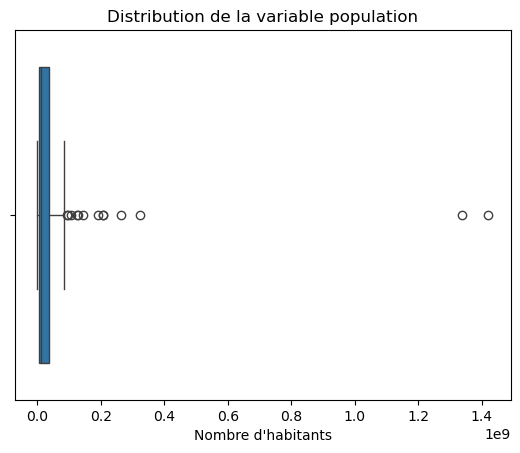

In [49]:
#Etude de la distribution
plt.title('Distribution de la variable population')
plt.xlabel("Nombre d'habitants")
sns.boxplot(x=df_population["Nombre d'habitants"])
plt.show()

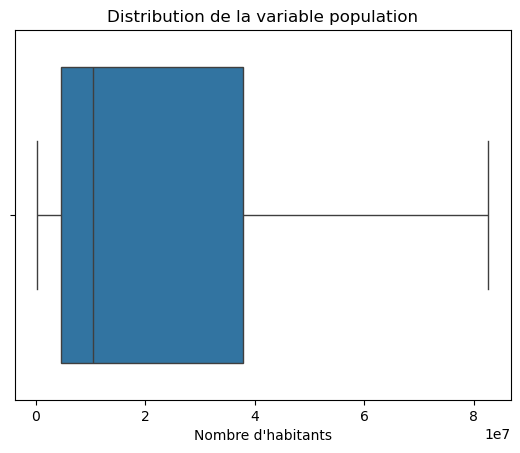

In [50]:
#Le box plot est très écrasé sur la gauche du fait de 2 pays avec une population particulièrement importante (outliers)
#Pour mieux visualiser le reste de la distribution des pays, on va refaire le boxplot mais sans les outliers
plt.title('Distribution de la variable population')
plt.xlabel("Nombre d'habitants")
sns.boxplot(x=df_population["Nombre d'habitants"],showfliers = False)
plt.show()

#### A.2 Consommation de viande de volailles

In [51]:
df_consommation = df_final[['Zone','Consommation de viande de volailles (kg/personne/an)']]

In [52]:
df_consommation.describe()

,Consommation de viande de volailles (kg/personne/an)
count,117.000000
mean,21.282479
std,13.724039
min,0.450000
25%,12.330000
50%,19.470000
75%,29.330000
max,67.390000


In [53]:
consommation_max = df_consommation["Consommation de viande de volailles (kg/personne/an)"].max()
consommation_min = df_consommation["Consommation de viande de volailles (kg/personne/an)"].min()
pays_consommation_max = df_consommation.loc[df_consommation["Consommation de viande de volailles (kg/personne/an)"] == consommation_max,'Zone'].item()
pays_consommation_min = df_consommation.loc[df_consommation["Consommation de viande de volailles (kg/personne/an)"] == consommation_min,'Zone'].item()
print(f"Pays avec la plus forte consommation (en 2017) : {pays_consommation_max} avec {consommation_max} kg par personne et par an\nPays avec la plus faible consommation (en 2017) : {pays_consommation_min} avec {consommation_min} kg par personne et par an")

Pays avec la plus forte consommation (en 2017) : Israël avec 67.39 kg par personne et par an
Pays avec la plus faible consommation (en 2017) : Tchad avec 0.45 kg par personne et par an


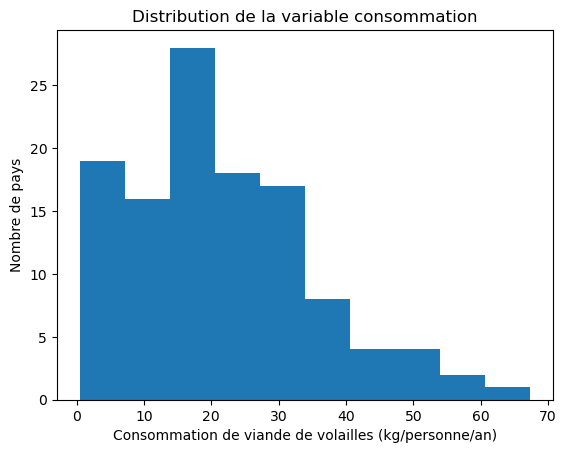

In [54]:
#Etude de la distribution
plt.title('Distribution de la variable consommation')
plt.xlabel("Consommation de viande de volailles (kg/personne/an)")
plt.ylabel("Nombre de pays")
plt.hist(df_consommation['Consommation de viande de volailles (kg/personne/an)'])
plt.show()

#### A.3 Exportation

In [55]:
df_exportation = df_final[['Zone',"Taux d'exportation"]]

In [56]:
df_exportation.describe()

,Taux d'exportation
count,117.000000
mean,20.615043
std,59.198110
min,0.000000
25%,0.000000
50%,1.810000
75%,14.160000
max,431.580000


In [57]:
exportation_max = df_exportation["Taux d'exportation"].max()
pays_exportation_max = df_exportation.loc[df_exportation["Taux d'exportation"] == exportation_max,'Zone'].item()
print(f"Pays analysé avec le taux d'exportation le plus important (en 2017) : {pays_exportation_max} avec {exportation_max}%")

Pays analysé avec le taux d'exportation le plus important (en 2017) : Belgique avec 431.58%


In [58]:
pays_sans_exportation = df_exportation.loc[df_exportation["Taux d'exportation"] == 0,'Zone'].unique()
print(f"Pays sans exportation de viande de volailles (en 2017) : {pays_sans_exportation}")

Pays sans exportation de viande de volailles (en 2017) : ['Albanie' 'Algérie' 'Angola' 'Arménie' 'Bénin' 'Botswana' 'Cameroun'
 'Congo' "Côte d'Ivoire" 'Équateur' 'Fidji' 'Gabon' 'Ghana' 'Guyana'
 'Îles Salomon' 'Indonésie' 'Iraq' 'Islande' 'Kenya' 'Kirghizistan'
 'Lesotho' 'Libéria' 'Malte' 'Monténégro' 'Myanmar' 'Nicaragua' 'Niger'
 'Nigéria' 'Norvège' 'Ouganda' 'Panama' 'République de Moldova' 'Rwanda'
 'Sénégal' 'Sierra Leone' 'Tchad' 'Togo' 'Trinité-et-Tobago'
 'Venezuela (République bolivarienne du)']


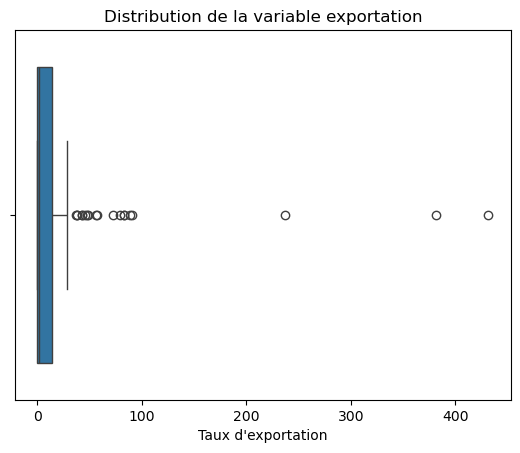

In [59]:
#Etude de la distribution
plt.title('Distribution de la variable exportation')
plt.xlabel("Taux d'exportation")
sns.boxplot(x=df_exportation["Taux d'exportation"])
plt.show()

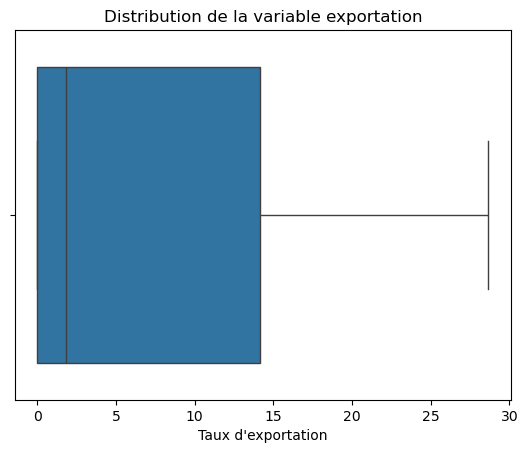

In [60]:
#sans les outliers
plt.title('Distribution de la variable exportation')
plt.xlabel("Taux d'exportation")
sns.boxplot(x=df_exportation["Taux d'exportation"],showfliers = False)
plt.show()

#### A.4 Importation

In [61]:
df_importation = df_final[['Zone','Taux de dépendance aux importations']]

In [62]:
df_importation.describe()

,Taux de dépendance aux importations
count,117.000000
mean,38.831709
std,49.836147
min,0.000000
25%,3.990000
50%,20.000000
75%,64.290000
max,323.930000


In [63]:
importation_max = df_importation["Taux de dépendance aux importations"].max()
pays_importation_max = df_importation.loc[df_importation["Taux de dépendance aux importations"] == importation_max,'Zone'].item()
print(f"Pays analysé avec le taux de dépendance aux importations le plus important (en 2017) : {pays_importation_max} avec {importation_max}%")

Pays analysé avec le taux de dépendance aux importations le plus important (en 2017) : Chine - RAS de Hong-Kong avec 323.93%


In [64]:
pays_sans_importation = df_importation.loc[df_importation["Taux de dépendance aux importations"] == 0,'Zone'].unique()
print(f"Pays sans importation de viande de volailles (en 2017) : {pays_sans_importation}")

Pays sans importation de viande de volailles (en 2017) : ['Cameroun' 'Équateur' 'Guyana' 'Inde' 'Israël' 'Kenya' 'Nigéria'
 'Ouganda' 'Rwanda' 'Sénégal' 'Tunisie']


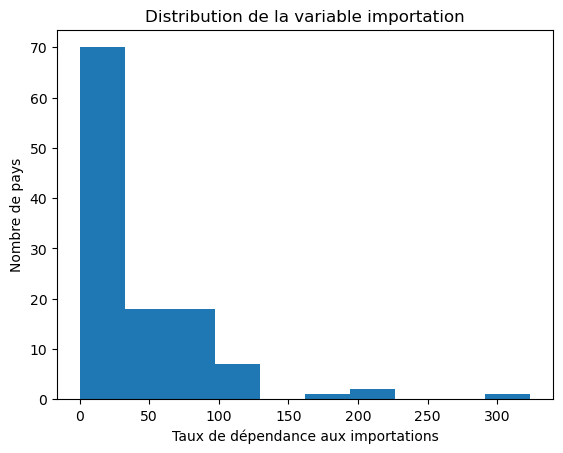

In [65]:
#Etude de la distribution
plt.title('Distribution de la variable importation')
plt.xlabel("Taux de dépendance aux importations")
plt.ylabel("Nombre de pays")
plt.hist(df_importation['Taux de dépendance aux importations'])
plt.show()

#### A.5 Score de stabilité politique

In [66]:
df_stabilite = df_final[['Zone','Score de stabilité politique']]

In [67]:
df_stabilite.describe()

,Score de stabilité politique
count,117.000000
mean,65.280573
std,13.991267
min,28.000404
25%,56.121815
50%,65.926074
75%,77.222615
max,91.388422


In [68]:
stabilite_min = df_stabilite["Score de stabilité politique"].min()
stabilite_max = df_stabilite["Score de stabilité politique"].max()
pays_stabilite_min = df_stabilite.loc[df_stabilite["Score de stabilité politique"] == stabilite_min,'Zone'].item()
pays_stabilite_max = df_stabilite.loc[df_stabilite["Score de stabilité politique"] == stabilite_max,'Zone'].item()
print(f"Pays analysé le plus stable (en 2017) : {pays_stabilite_max} avec un score de {round(stabilite_max,2)} \nPays analysé le moins stable (en 2017) : {pays_stabilite_min} avec un score de {round(stabilite_min,2)}")

Pays analysé le plus stable (en 2017) : Nouvelle-Zélande avec un score de 91.39 
Pays analysé le moins stable (en 2017) : Pakistan avec un score de 28.0


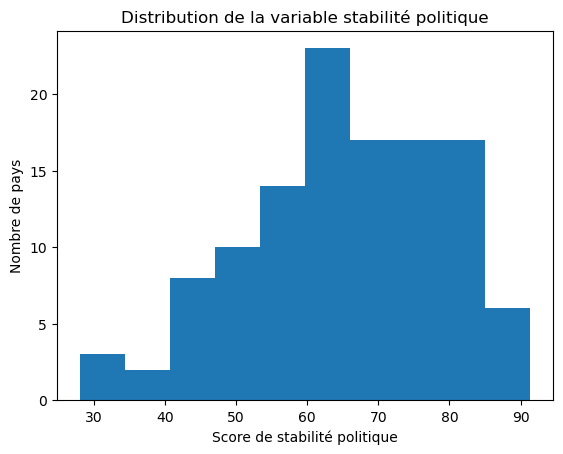

In [69]:
#Etude de la distribution
plt.title('Distribution de la variable stabilité politique')
plt.xlabel("Score de stabilité politique")
plt.ylabel("Nombre de pays")
plt.hist(df_stabilite['Score de stabilité politique'])
plt.show()

#### A.6 Indice de performance logistique

In [70]:
df_logistique = df_final[['Zone','Indice de performance logistique']]

In [71]:
df_logistique.describe()

,Indice de performance logistique
count,117.000000
mean,3.017633
std,0.600854
min,2.025402
25%,2.531062
50%,2.962629
75%,3.423693
max,4.225967


In [72]:
logistique_min = df_logistique["Indice de performance logistique"].min()
logistique_max = df_logistique["Indice de performance logistique"].max()
pays_logistique_min = df_logistique.loc[df_logistique["Indice de performance logistique"] == logistique_min,'Zone'].item()
pays_logistique_max = df_logistique.loc[df_logistique["Indice de performance logistique"] == logistique_max,'Zone'].item()
print(f"Pays analysé avec l'indice de performance logistique le plus élevé (en 2017) : {pays_logistique_max} avec un indice de {round(logistique_max,2)} \nPays analysé avec l'indice de performance logistique le moins élevé (en 2017) : {pays_logistique_min} avec un indice de {round(logistique_min,2)}")

Pays analysé avec l'indice de performance logistique le plus élevé (en 2017) : Allemagne avec un indice de 4.23 
Pays analysé avec l'indice de performance logistique le moins élevé (en 2017) : Sierra Leone avec un indice de 2.03


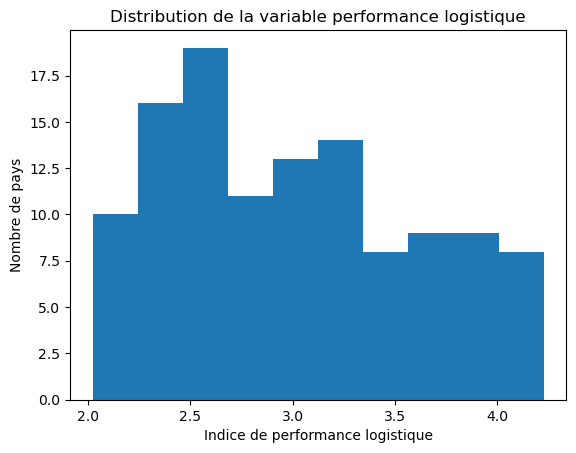

In [73]:
#Etude de la distribution
plt.title('Distribution de la variable performance logistique')
plt.xlabel("Indice de performance logistique")
plt.ylabel("Nombre de pays")
plt.hist(df_logistique['Indice de performance logistique'])
plt.show()

#### A.7 PIB par habitant (en $US)

In [74]:
df_pib = df_final[['Zone','PIB par habitant (en $US)']]

In [75]:
df_pib.describe()

,PIB par habitant (en $US)
count,117.000000
mean,17042.700757
std,20949.991152
min,521.804130
25%,3296.526611
50%,6921.733731
75%,21442.384277
max,110193.213797


In [76]:
pib_min = df_pib["PIB par habitant (en $US)"].min()
pib_max = df_pib["PIB par habitant (en $US)"].max()
pays_pib_min = df_pib.loc[df_pib["PIB par habitant (en $US)"] == pib_min,'Zone'].item()
pays_pib_max = df_pib.loc[df_pib["PIB par habitant (en $US)"] == pib_max,'Zone'].item()
print(f"Pays analysé avec le PIB par habitant le plus élevé (en 2017) : {pays_pib_max} avec un PIB de {round(pib_max,2)} $US \nPays analysé avec le PIB par habitant le moins élevé (en 2017) : {pays_pib_min} avec un PIB de {round(pib_min,2)} $US")

Pays analysé avec le PIB par habitant le plus élevé (en 2017) : Luxembourg avec un PIB de 110193.21 $US 
Pays analysé avec le PIB par habitant le moins élevé (en 2017) : Niger avec un PIB de 521.8 $US


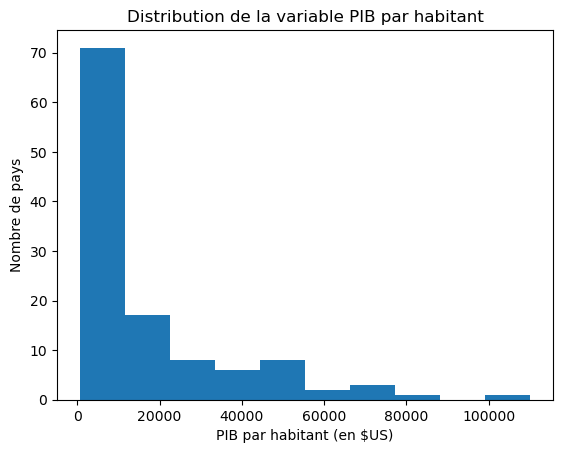

In [77]:
#Etude de la distribution
plt.title('Distribution de la variable PIB par habitant')
plt.xlabel("PIB par habitant (en $US)")
plt.ylabel("Nombre de pays")
plt.hist(df_pib['PIB par habitant (en $US)'])
plt.show()

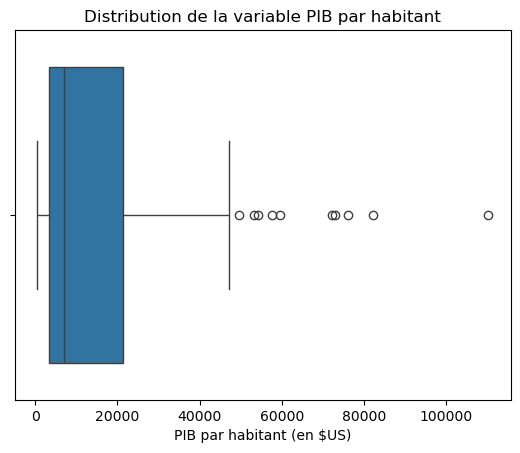

In [78]:
#Etude de la distribution
plt.title('Distribution de la variable PIB par habitant')
plt.xlabel("PIB par habitant (en $US)")
sns.boxplot(x=df_pib["PIB par habitant (en $US)"])
plt.show()

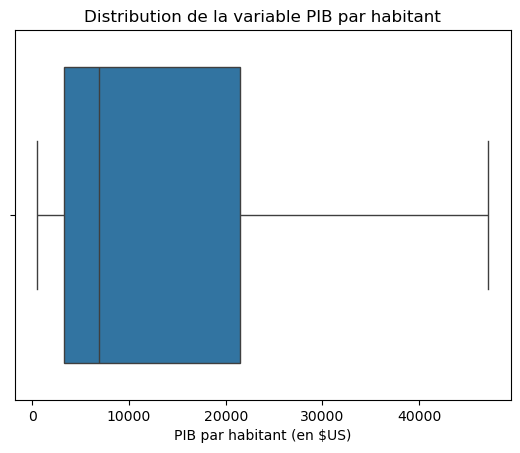

In [79]:
#Sans les outliers
plt.title('Distribution de la variable PIB par habitant')
plt.xlabel("PIB par habitant (en $US)")
sns.boxplot(x=df_pib["PIB par habitant (en $US)"],showfliers=False)
plt.show()

#### A.8 Climat des affaires

In [80]:
df_climat = df_final[['Zone','Climat des affaires']]

In [81]:
df_climat.describe()

,Climat des affaires
count,117.000000
mean,65.312595
std,12.577045
min,31.120130
25%,57.244300
50%,65.641890
75%,75.410480
max,87.166330


In [82]:
climat_min = df_climat["Climat des affaires"].min()
climat_max = df_climat["Climat des affaires"].max()
pays_climat_min = df_climat.loc[df_climat["Climat des affaires"] == climat_min,'Zone'].item()
pays_climat_max = df_climat.loc[df_climat["Climat des affaires"] == climat_max,'Zone'].item()
print(f"Pays analysé avec le climat des affaires le plus propice (en 2017) : {pays_climat_max} avec un score de {round(climat_max,2)} \nPays analysé avec le climat des affaires le moins propice (en 2017) : {pays_climat_min} avec un score de {round(climat_min,2)}")

Pays analysé avec le climat des affaires le plus propice (en 2017) : Nouvelle-Zélande avec un score de 87.17 
Pays analysé avec le climat des affaires le moins propice (en 2017) : Venezuela (République bolivarienne du) avec un score de 31.12


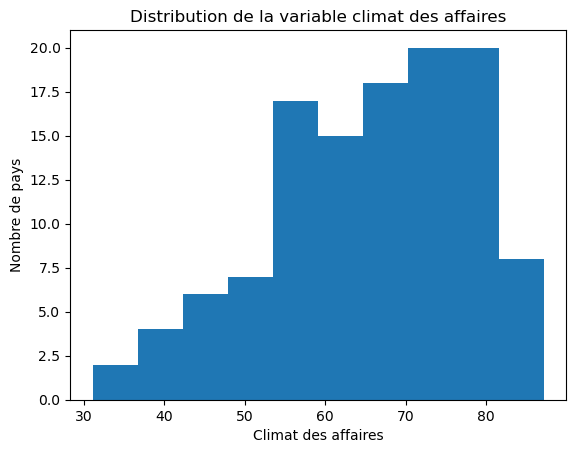

In [83]:
#Etude de la distribution
plt.title('Distribution de la variable climat des affaires')
plt.xlabel("Climat des affaires")
plt.ylabel("Nombre de pays")
plt.hist(df_climat['Climat des affaires'])
plt.show()

#### A.9 Distance avec la France

In [84]:
df_distance = df_final[['Zone','Distance avec la France (en km)']]

In [85]:
df_distance.describe()

,Distance avec la France (en km)
count,117.000000
mean,5374.442006
std,3903.931308
min,473.667855
25%,1889.735918
50%,4468.210971
75%,8456.791020
max,19161.886131


In [86]:
distance_min = df_distance["Distance avec la France (en km)"].min()
distance_max = df_distance["Distance avec la France (en km)"].max()
pays_distance_min = df_distance.loc[df_distance["Distance avec la France (en km)"] == distance_min,'Zone'].item()
pays_distance_max = df_distance.loc[df_distance["Distance avec la France (en km)"] == distance_max,'Zone'].item()
print(f"Pays analysé le plus loin du pays de production (en 2017) : {pays_distance_max} avec {round(distance_max,2)} km à vol d'oiseau \nPays analysé le plus proche du pays de production (en 2017) : {pays_distance_min} avec {round(distance_min,2)} km à vol d'oiseau")

Pays analysé le plus loin du pays de production (en 2017) : Nouvelle-Zélande avec 19161.89 km à vol d'oiseau 
Pays analysé le plus proche du pays de production (en 2017) : Suisse avec 473.67 km à vol d'oiseau


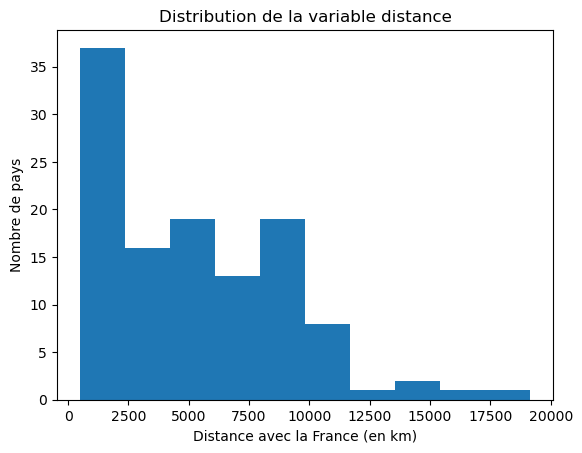

In [87]:
#Etude de la distribution
plt.title('Distribution de la variable distance')
plt.xlabel("Distance avec la France (en km)")
plt.ylabel("Nombre de pays")
plt.hist(df_distance['Distance avec la France (en km)'])
plt.show()

### B. Etude des corrélations entre variables

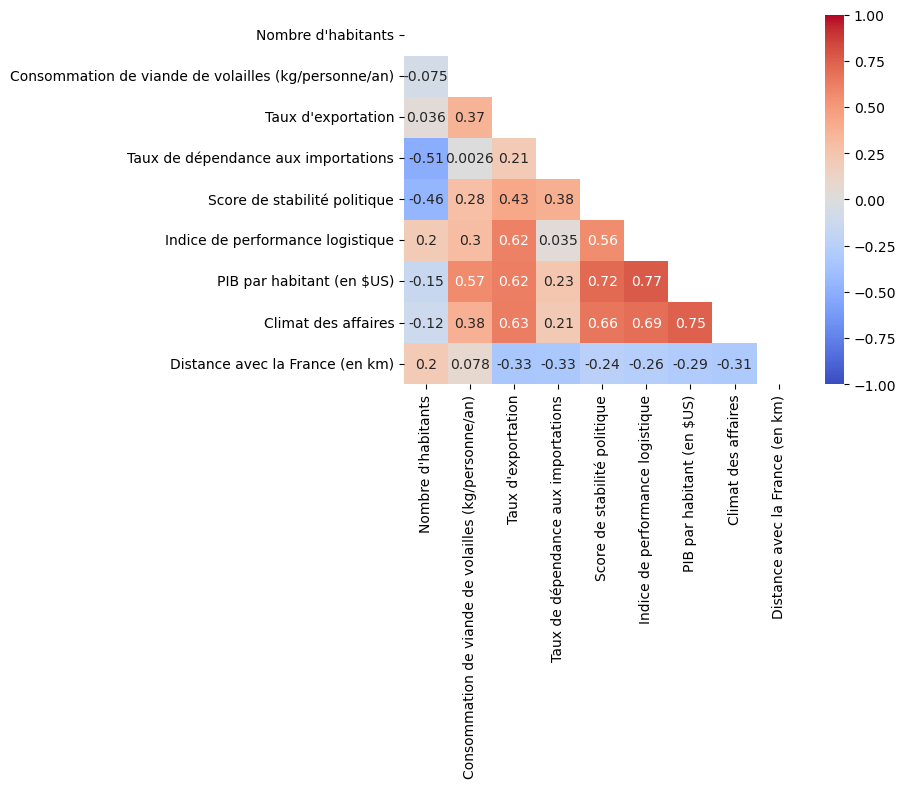

In [90]:
#Comme les distributions des différentes variables n'apparaissent pas comme normales, on va étudier les corrélations avec le coefficient de Spearman
#Création d'une heatmap de corrélation
df_corr = df_final[["Nombre d'habitants",'Consommation de viande de volailles (kg/personne/an)',"Taux d'exportation",'Taux de dépendance aux importations','Score de stabilité politique','Indice de performance logistique','PIB par habitant (en $US)','Climat des affaires','Distance avec la France (en km)']]
corr = df_corr.corr(method='spearman')
#On peut également créer un mask pour n'afficher qu'une demi heatmap (pour améliorer la lisibilité)
ones = np.ones_like(corr) #création d'un array de 1 de la même taille que le df étudié
mask = np.triu(ones,k=0).astype(bool) #remplacement de la partie inférieure de cet array 
#par des 0 en gardant la diagonale avec 1 puis remplacement des 0 et 1 par des booléens 
#pour lecture par la heatmap
sns.heatmap(corr,cmap='coolwarm',annot=True,vmin=-1,vmax=1,mask=mask) #ajout du mask dans la 
#heatmap. Toutes les cases = True sont masquées.
plt.show()

Corrélations à noter :
- PIB par habitant / Indice de performance logistique (0.77) : l'indice augmente avec le PIB
- Climat des affaires / PIB par habitant (0.75) : Le climat augmente avec le PIB
- PIB par habitant / Score de stabilité politique (0.72) : Le score augmente avec le PIB
- Score de stabilité / Nombre d'habitants (-0.46) : Le score baisse lorsque le nombre d'habitants augmente

On peut déjà entrevoir des liens entre les variables, notamment PIB, Climat des affaires, Performance logistique et Stabilité politique qui pourraient correspondre au développement économique d'un pays. On pourra ensuite confirmer cela grâce à l'ACP.